# Capstone Function 5
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. 

Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

 Input | Output | Goal |
|-------|--------|------|
| 3D Array (20, 4) | 1D Array (20, ) | Maximise |

# Exploratory Data Analysis

In [1]:
# load and view a .npy file
import numpy as np
from matplotlib import pyplot as plt
import sys
# load the .npy file
initial_inputs = np.load("data/initial_inputs.npy")
initial_outputs = np.load("data/initial_outputs.npy")
# summarize shape
print(initial_inputs.shape)
print(initial_outputs.shape)

# create a dataframe from inputs and outputs
import pandas as pd
data = pd.DataFrame(initial_inputs, columns=[f'input_{i}' for i in range(initial_inputs.shape[1])])
data['output'] = initial_outputs
print(data.head(20))

# save the data as a CSV file
data.to_csv("data/initial_data.csv", index=False)

(20, 4)
(20,)
     input_0   input_1   input_2   input_3       output
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.088947  

## Observations


# Gaussian Process with EI, PI and UCB

Next (UCB): [0.23691046 0.73897451 0.98534431 0.99229516]
Next (EI):  [0.23940317 0.90709429 0.97635463 0.95941244]
Next (PI):  [0.43417565 0.82542745 0.50358573 0.91108015]


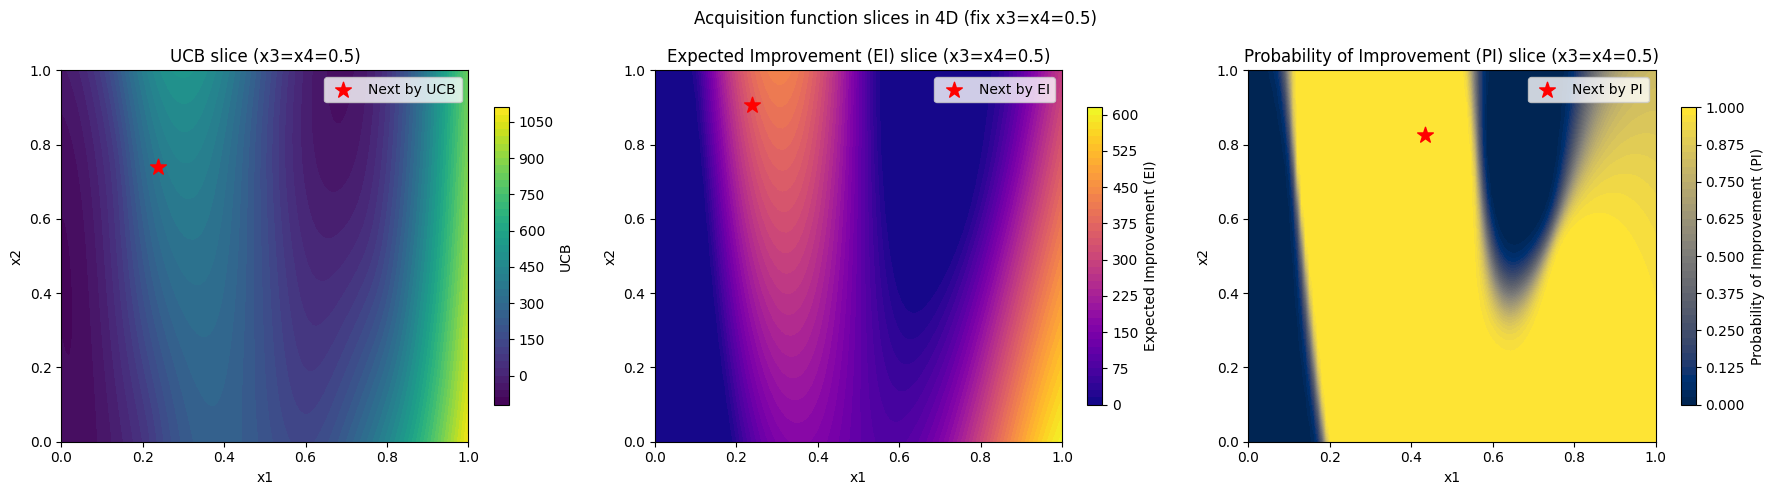

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm, qmc  # norm for EI/PI, qmc for Latin Hypercube

# ----------------------------------------------------------
# 1) GP model utilities
# ----------------------------------------------------------
def fit_gp(X, y):
    """
    Fit a Gaussian Process with ARD RBF kernel on 4D inputs.
    Assumes X is scaled to [0,1]^4 (recommended).
    """
    kernel = C(1.0, (1e-3, 1e3)) * RBF(
        length_scale=[0.3, 0.3, 0.3, 0.3],
        length_scale_bounds=(1e-2, 1e2)
    )
    gp = GaussianProcessRegressor(
        kernel=kernel,
        n_restarts_optimizer=5,
        alpha=1e-4,          # small noise term; tune for your data
        normalize_y=True
    )
    gp.fit(X, y)
    return gp

def compute_acquisitions(gp, Xcand, best_y=None, xi=0.01, kappa=2.0):
    """
    Compute UCB, EI, PI for candidate points.
    - gp: fitted GaussianProcessRegressor
    - Xcand: candidate points (m×4) in [0,1]^4
    - best_y: current best observed output (if None, take max of training y)
    - xi: small improvement margin for EI/PI
    - kappa: exploration weight for UCB
    Returns: (ucb, ei, pi, mean, std)
    """
    mean, std = gp.predict(Xcand, return_std=True)
    std = np.maximum(std, 1e-12)  # numerical safety (avoid divide-by-zero)

    if best_y is None:
        best_y = np.max(gp.y_train_)  # since normalize_y=True, this is okay for selection

    # UCB: mu + kappa*sigma
    ucb = mean + kappa * std

    # EI: (mu - best - xi) * Phi(z) + sigma * phi(z)
    z  = (mean - best_y - xi) / std
    ei = (mean - best_y - xi) * norm.cdf(z) + std * norm.pdf(z)

    # PI: Phi(z)
    pi = norm.cdf(z)

    return ucb, ei, pi, mean, std

def choose_next(Xcand, acq_values):
    """Return next point by maximizing the acquisition."""
    idx = int(np.argmax(acq_values))
    return Xcand[idx], idx

# ----------------------------------------------------------
# 2) Slice visualisation utilities (2D views in a 4D space)
# ----------------------------------------------------------
def make_slice(gp, which='12', grid=100, fixed=(0.5, 0.5), xi=0.01, kappa=2.0):
    """
    Compute a 2D slice of UCB, EI, PI.
    which='12' -> slice over (x1,x2) with (x3,x4)=fixed
    which='34' -> slice over (x3,x4) with (x1,x2)=fixed
    Returns (X1, X2, UCB_slice, EI_slice, PI_slice)
    """
    x = np.linspace(0, 1, grid)
    X1, X2 = np.meshgrid(x, x)
    if which == '12':
        Xslice = np.column_stack([
            X1.ravel(), X2.ravel(),
            np.full(grid*grid, fixed[0]), np.full(grid*grid, fixed[1])
        ])
    else:
        Xslice = np.column_stack([
            np.full(grid*grid, fixed[0]), np.full(grid*grid, fixed[1]),
            X1.ravel(), X2.ravel()
        ])
    ucb, ei, pi, _, _ = compute_acquisitions(gp, Xslice, xi=xi, kappa=kappa)
    return X1, X2, ucb.reshape(grid, grid), ei.reshape(grid, grid), pi.reshape(grid, grid)

#-------------------- Main Program --------------------

# Load the dataset
X = np.load("initial_inputs.npy")
y = np.load("initial_outputs.npy")

# Fit GP
gp = fit_gp(X, y)

# Candidate set via Latin Hypercube in [0,1]^4
M = 6000
sampler = qmc.LatinHypercube(d=4, seed=123)
Xcand = sampler.random(M)

# Compute acquisitions and pick next points for UCB, EI, PI
kappa = 2.0  # ↑ explore; ↓ exploit
xi    = 0.01 # small margin for EI/PI
ucb_vals, ei_vals, pi_vals, _, _ = compute_acquisitions(gp, Xcand, xi=xi, kappa=kappa)
next_ucb, idx_ucb = choose_next(Xcand, ucb_vals)
next_ei,  idx_ei  = choose_next(Xcand, ei_vals)
next_pi,  idx_pi  = choose_next(Xcand, pi_vals)

print("Next (UCB):", next_ucb)
print("Next (EI): ", next_ei)
print("Next (PI): ", next_pi)

# ---- Visualise acquisition slices over (x1, x2) at (x3, x4) = 0.5 ----
X1, X2, UCB_s, EI_s, PI_s = make_slice(
    gp, which='12', grid=100, fixed=(0.5, 0.5), xi=xi, kappa=kappa
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps  = ['viridis', 'plasma', 'cividis']
labels = ['UCB', 'Expected Improvement (EI)', 'Probability of Improvement (PI)']
arrays = [UCB_s, EI_s, PI_s]

for ax, arr, lab, cmap in zip(axes, arrays, labels, cmaps):
    cs = ax.contourf(X1, X2, arr, levels=40, cmap=cmap)
    ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_title(lab + ' slice (x3=x4=0.5)')
    fig.colorbar(cs, ax=ax, shrink=0.8, label=lab)

# Overlay the projected best-next points onto this slice
axes[0].scatter(next_ucb[0], next_ucb[1], c='red', marker='*', s=140, label='Next by UCB')
axes[1].scatter(next_ei[0],  next_ei[1],  c='red', marker='*', s=140, label='Next by EI')
axes[2].scatter(next_pi[0],  next_pi[1],  c='red', marker='*', s=140, label='Next by PI')
for ax in axes:
    ax.legend(loc='upper right')

plt.suptitle('Acquisition function slices in 4D (fix x3=x4=0.5)')
plt.tight_layout()
plt.savefig('acq_slices_4d.png')  # saved image file
plt.show()


# Week 1 Submission
0.434175-0.825427-0.503585-0.911080

---
---
# Week 2
Try to improve the process:
1. Build a SMBO (Sequential Model Based Optimisation) process to iteratively add new samples as they become available.
2. Visualize the performance - convergence
3. True to improve the various parameters!
4. Review which acquisition function to use

Suggested new points: [[0.3499894843590963, 0.8461961449789507, 0.8988880508479277, 0.8923993189734801]]


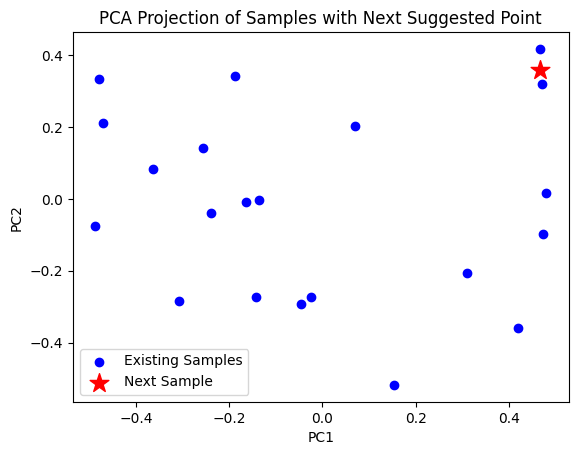

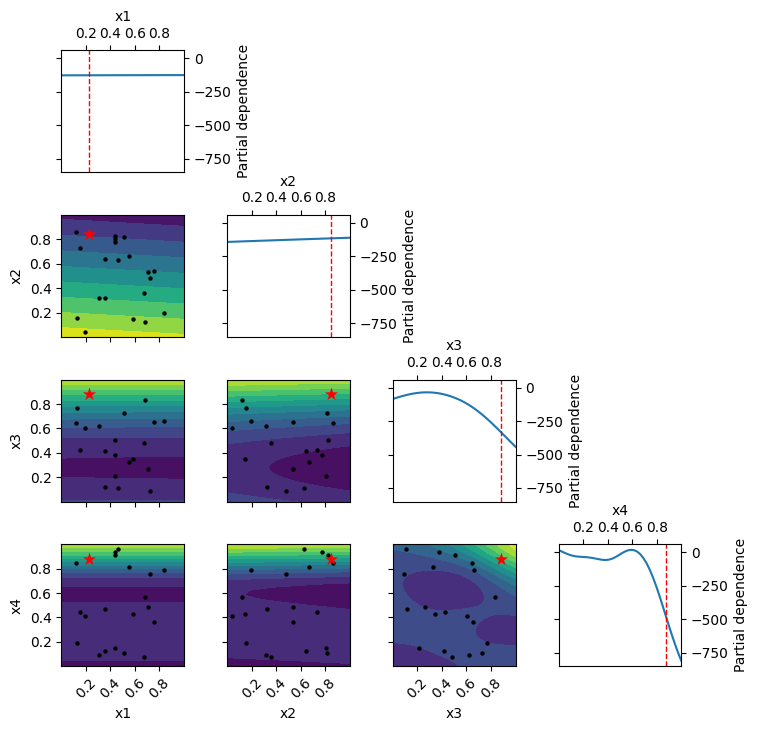

In [7]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="PI", random_state=42)

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.434175, 0.825427, 0.503585, 0.911080])
y.append(438.991487)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_points = opt.ask(n_points=1)  # propose new point
print("Suggested new points:", next_points)

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_points))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)


## Submission
0.349989-0.846196-0.898888-0.892399

---
---
# Week 3

Suggested new points: 0.900721-0.000000-1.000000-1.000000


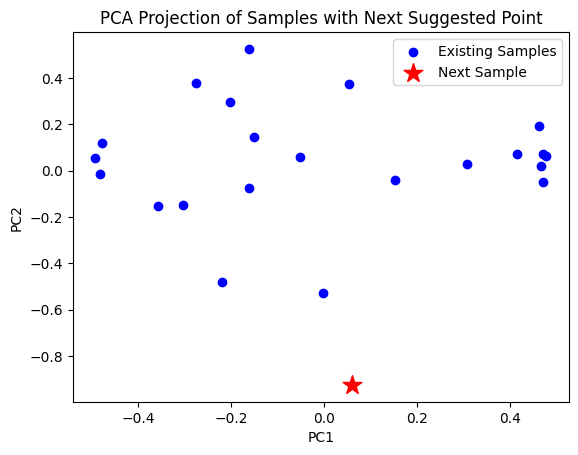

00. X: 0.191447, 0.038193, 0.607418, 0.414584, y:       64.443440
01. X: 0.758653, 0.536518, 0.656000, 0.360342, y:       18.301380
02. X: 0.438350, 0.804340, 0.210245, 0.151295, y:        0.112940
03. X: 0.706051, 0.534192, 0.264243, 0.482088, y:        4.210898
04. X: 0.836478, 0.193610, 0.663893, 0.785649, y:      258.370525
05. X: 0.683432, 0.118663, 0.829046, 0.567577, y:       78.434389
06. X: 0.553621, 0.667350, 0.323806, 0.814870, y:       57.571537
07. X: 0.352356, 0.322242, 0.116979, 0.473113, y:      109.571876
08. X: 0.153786, 0.729382, 0.422598, 0.443074, y:        8.847992
09. X: 0.463442, 0.630025, 0.107906, 0.957644, y:      233.223610
10. X: 0.677491, 0.358510, 0.479592, 0.072880, y:       24.423088
11. X: 0.583973, 0.147243, 0.348097, 0.428615, y:       64.420147
12. X: 0.306889, 0.316878, 0.622634, 0.095399, y:       63.476716
13. X: 0.511142, 0.817957, 0.728710, 0.112354, y:       79.729130
14. X: 0.438933, 0.774092, 0.378167, 0.933696, y:      355.806818
15. X: 0.2

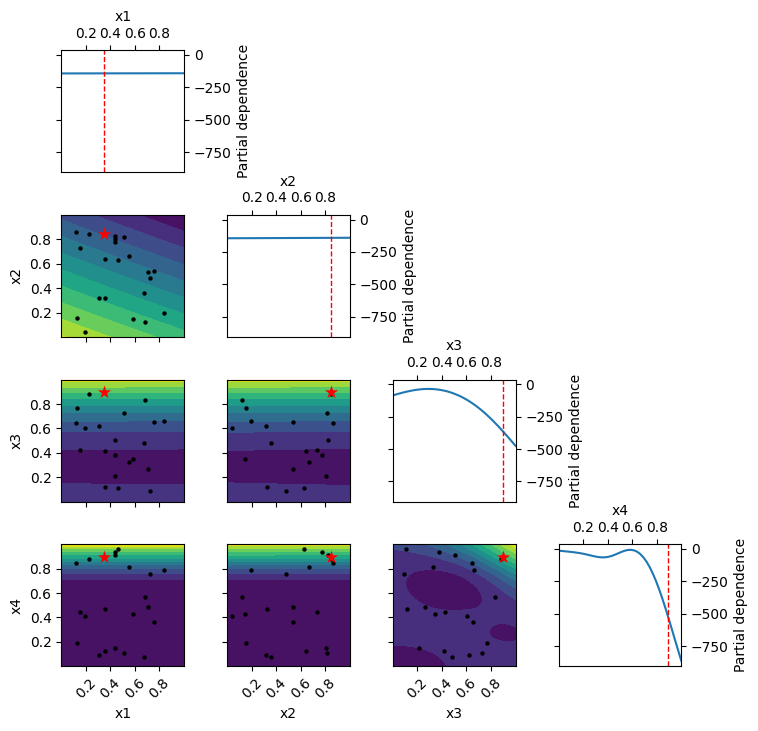

In [6]:

from skopt import Optimizer
from skopt.plots import plot_objective
from skopt.space import Real
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator="GP", acq_func="EI", random_state=42, acq_func_kwargs={'xi': 0.0})

# 3. Existing data (10 samples)
X = np.load("data/initial_inputs.npy").tolist()
y = np.load("data/initial_outputs.npy").tolist()

# insert a new observation at end of X and y (negate y for maximisation)
X.append([0.434175, 0.825427, 0.503585, 0.911080])
y.append(438.991487)

# insert a new observation for week 3
X.append([0.349989, 0.846196, 0.898888, 0.892399])
y.append(1280.357170)

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose new point
print(f"Suggested new points: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}")

# Use PCA to plot the next sample in 2D
pca = PCA(n_components=2)
proj = pca.fit_transform(np.array(X + next_point))
plt.scatter(proj[:-1, 0], proj[:-1, 1], c='blue', label='Existing Samples')
plt.scatter(proj[-1, 0], proj[-1, 1], c='red', label='Next Sample', marker='*', s=200)
plt.title('PCA Projection of Samples with Next Suggested Point')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

_ = plot_objective(res)

# negate all the y values back to original
y = [-val for val in y]

# Print X and y in a formatted way with unpacked coordinates
max_y_index = np.argmax(y)
# Use fixed width for y column (easier to read)
for i in range(len(X)):
    x_str = ", ".join(f"{val:.6f}" for val in X[i])
    
    # Right-align y values in 15 character width
    y_str = f"{y[i]:>15.6f}"
    
    if i == max_y_index:
        print(f"{i:02d}. \033[92mX: {x_str}, y: {y_str}\033[0m")
    else:
        print(f"{i:02d}. X: {x_str}, y: {y_str}")

---
---
# Week 4

## Hyperparamter Tuning - encourage exploitation

Suggested new point: 0.604461-0.766300-0.901927-0.999774


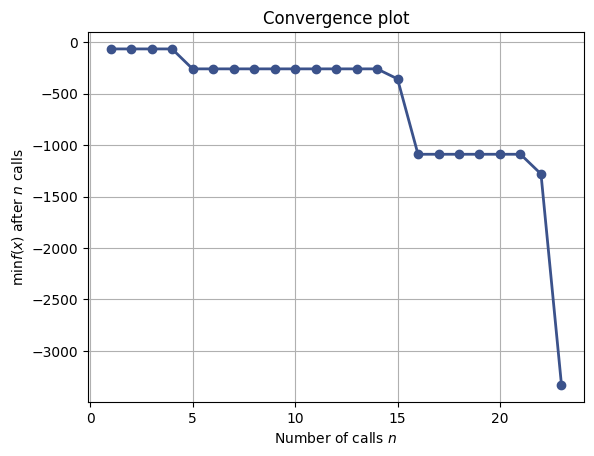

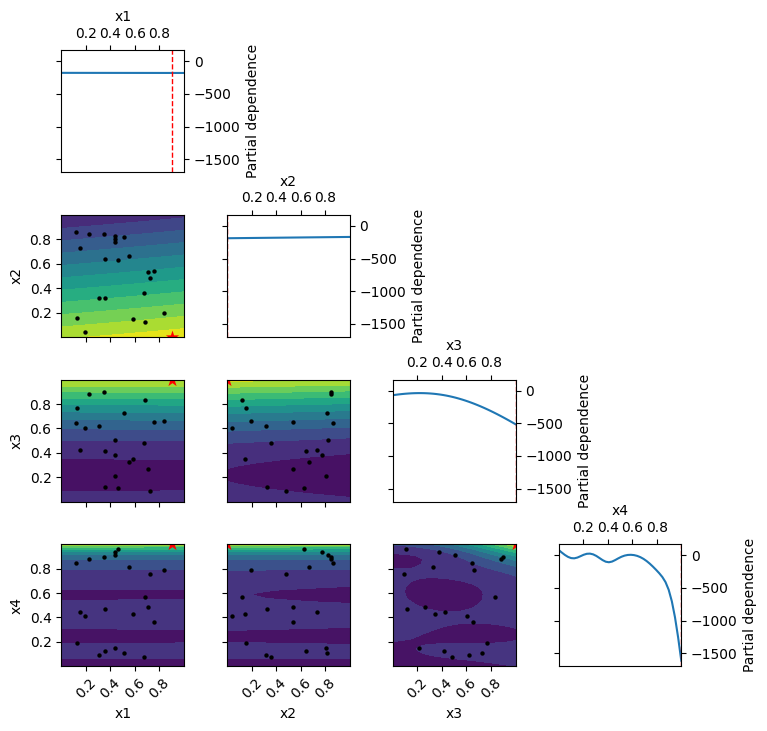

In [5]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.0}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data ()
X = np.load("../data/f5/updated_inputs.npy").tolist()
y = np.load("../data/f5/updated_outputs.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)




---
---
# Week 5

## Hyperparamter Tuning - encourage exploitation

Suggested new point: 0.636948-0.031197-0.919751-0.997885


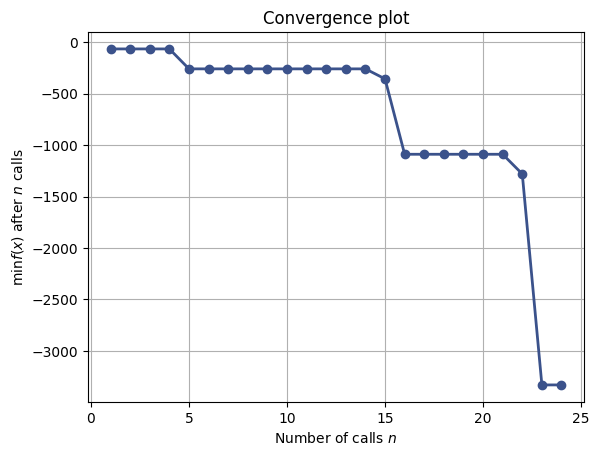

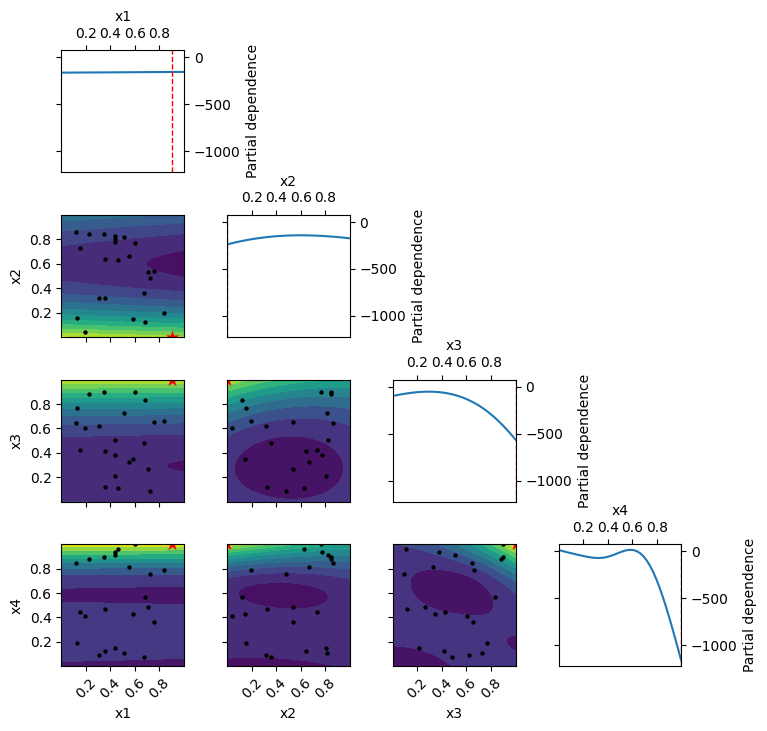

In [6]:
from skopt import Optimizer
from skopt.plots import plot_objective, plot_convergence
from skopt.space import Real
import numpy as np

# 1. Define search space
space = [Real(0.0, 1.0, name='x1'),
         Real(0.0, 1.0, name='x2'),
         Real(0.0, 1.0, name='x3'),
         Real(0.0, 1.0, name='x4')]

# set the hyperparameters for Optimizer
base_estimator = "GP"
acq_func = "EI"
random_state = 42
acq_func_kwargs = {'xi': 0.0}

# 2. Create Optimizer
opt = Optimizer(dimensions=space, base_estimator=base_estimator, acq_func=acq_func, random_state=random_state, acq_func_kwargs=acq_func_kwargs)

# 3. Existing data ()
X = np.load("../data/f5/updated_inputs - Week 4.npy").tolist()
y = np.load("../data/f5/updated_outputs - Week 4.npy").tolist()

# negate the y values for maximisation
y = [-val for val in y]

# 4. Seed the optimiser
res = opt.tell(X, y)

# 5. Ask for new candidate points (no objective function needed)
next_point = opt.ask(n_points=1)  # propose next point
print(f"Suggested new point: {next_point[0][0]:.6f}-{next_point[0][1]:.6f}-{next_point[0][2]:.6f}-{next_point[0][3]:.6f}")

# plot the convergence
__ = plot_convergence(res)

# plot the objective function
_ = plot_objective(res)


